In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [47]:
plt.rcParams["figure.figsize"] = [12, 6]   
# plt.rcParams['figure.dpi'] = 300           ## 300 for printing
plt.rc('font', size=8)                     
plt.rc('axes', titlesize=16)               
plt.rc('axes', labelsize=14)               
plt.rc('xtick', labelsize=10)              
plt.rc('ytick', labelsize=10)              
plt.rc('legend', fontsize=10)              
plt.rc('figure', titlesize=12) 

This area covers the following:
* Forecasting with an RNN using Keras
* Forecasting with LSTM using Keras
* Forecasting with a GRU using Keras
* Forecasting with an RNN using PyTorch
* Forecasting with LSTM using PyTorch
* Forecasting with a GRU using PyTorch

In [2]:
def one_step_forecast(df, window):
    '''
    This function forecasts only one step forward

    df: dataframe for forecast
    window: number of steps or observation backward used to forecast one step forward
    '''
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]

    for start in range(n-window):
        end = start + window
        x.append(d[start:end])

    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)

    return pd.concat([df_y, df_xs], axis=1).dropna()

In [3]:
class Standardize:
    def __init__(self, df, split=0.10):
        self.data = df
        self.split = split

    def split_data(self):
        n = int(len(self.data) * self.split)
        train, test = self.data.iloc[:-n], self.data.iloc[-n:]
        n = int(len(train) * self.split)
        train, val = train.iloc[:-n], train.iloc[-n:]
        assert len(test) + len(train) + len(val) == len(self.data)

        return train, test, val

    def _transform(self, data):
        data_s = (data - self.mu) / self.sigma

        return data_s

    def fit_transform(self):
        train, test, val = self.split_data()
        self.mu, self.sigma = train.mean(), train.std()
        train_s = self._transform(train)
        test_s = self._transform(test)
        val_s = self._transform(val)

        return train_s, test_s, val_s

    def inverse(self, data):
        return (data * self.sigma) + self.mu

    def inverse_y(self, data):
        return (data * self.sigma[-1]) + self.mu[-1]

In [4]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch12')
energy = pd.read_csv(path.joinpath('energy_consumption.csv'), index_col='Month', parse_dates=True)
energy.columns = ['y']
energy.index.freq = 'MS'
en_df = one_step_forecast(energy, 10)

In [5]:
scale_energy = Standardize(en_df)
train_energy, test_energy, val_energy = scale_energy.fit_transform()

### 1. Forecasting with an RNN using Keras

RNNs initially entered the spotlight with Natural Language Processing (NLP), as they were designed for sequential data, where past observations, such as words, have a strong influence on determining the next word in a sentence. This need for the artificial neural network to retain memory (hidden state) inspired the RNN architecture. Similarly, time series data is also sequential, and since past observations influence future observations, it also needs a network with memory.

In RNNs, there is a feedback loop where the output of one node or neuron is fed back (the recursive part) as input, allowing the network to learn from a prior time step acting as a memory.

In [6]:
from tensorflow.keras import Sequential
from tensorflow import keras
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from keras.layers import Dense, SimpleRNN, Dropout

2025-01-27 16:40:24.533367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737985224.984063   45707 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737985225.122861   45707 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-27 16:40:26.365082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
def features_target_ts(*args):
    '''
    This function takes a dataset and returns an x split (independent vars) and y (dependent vars)
    '''
    y = [col.pop('y').values.reshape(-1, 1) for col in args]
    x = [col.values.reshape(*col.shape, 1) for col in args]
    
    return *y, *x

In [8]:
(y_train_en, y_val_en, y_test_en, x_train_en, x_val_en, x_test_en) = features_target_ts(train_energy, val_energy, test_energy)

In [28]:
def create_model(train, units, dropout=0.2):
    '''
    This function is used to construct the network's architecture.

    train:
    units:
    dropout:
    '''
    model = keras.Sequential()
    model.add(SimpleRNN(units=units, return_sequences=False, input_shape=(train.shape[1], train.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=units, input_shape=(train.shape[1], train.shape)))

    return model

In [15]:
def train_model_ts(model, x_train, y_train, x_val, y_val, epochs=500, patience=12, batch_size=32):
    '''
    This function, takes as input the returned Sequential object (which we are calling model), and the 
    training and validation sets. The function will compile and train the model on the training sets and use the
    validation sets for evaluation at each epoch. During the training process, it will print
    output at each epoch, displaying the scores against the training and validation sets.
    '''
    model.compile(optimizer='adam', loss='mean_squared_error', 
                  metrics=[RootMeanSquaredError(), MeanAbsoluteError()])
    
    es = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=patience)

    history = model.fit(x_train, y_train, 
                        shuffle=False, epochs=epochs, batch_size=batch_size, 
                        validation_data=(x_val, y_val), callbacks=[es], verbose=1)
    
    return history

In [16]:
def plot_forecast(model, x_test, y_test, index, history):
    '''
    This function, takes the model object to make a prediction (forecast) and print out the predicted values against 
    the actual values (out-of-sample) in the test set. Additionally, the function takes the history dictionary to plot 
    the model's performance during training, so you can visually evaluate the model for any signs of overfitting.
    '''
    fig, ax = plt.subplots(2, 1)
    (pd.Series(history.history['loss']) \
     .plot(style='k', alpha=0.50, title='Loss by Epoch', ax = ax[0], label='loss'))
    (pd.Series(history.history['val_loss']).plot(style='k', ax=ax[0], label='val_loss'))
    ax[0].legend()

    predicted = model.predict(x_test)
    pd.Series(y_test.reshape(-1), index=index) \
        .plot(style='k--', alpha=0.5, ax=ax[1], title='Forecast vs Actual', label='actual')
    pd.Series(predicted.reshape(-1), index=index).plot(style='k', label='Forecast', ax=ax[1])
    fig.tight_layout()
    ax[1].legend(); plt.show()

In [29]:
model_en_simpleRNN = create_model(train=x_train_en, units=32)

In [30]:
model_en_simpleRNN.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,144 (8.38 KB)

 Trainable params: 2,144 (8.38 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_en_simpleRNN = train_model_ts(model_en_simpleRNN, x_train_en, y_train_en, x_val_en, y_val_en, batch_size=64)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 1.2474 - mean_absolute_error: 0.9394 - root_mean_squared_error: 1.1156 - val_loss: 1.4827 - val_mean_absolute_error: 0.8956 - val_root_mean_squared_error: 1.2177
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0760 - mean_absolute_error: 0.8756 - root_mean_squared_error: 1.0363 - val_loss: 1.3409 - val_mean_absolute_error: 0.8535 - val_root_mean_squared_error: 1.1580
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9620 - mean_absolute_error: 0.8301 - root_mean_squared_error: 0.9799 - val_loss: 1.2217 - val_mean_absolute_error: 0.8175 - val_root_mean_squared_error: 1.1053
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8574 - mean_absolute_error: 0.7830 - root_mean_squared_error: 0.9252 - val_loss: 1.1101 - val_mean_absolute_error: 0.7830 - val_root_mean_squared_error: 1.0536
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7794 - mean_absolute_error: 0.7449 - root_mean_squared_error

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


ValueError: Length of values (1824) does not match length of index (57)

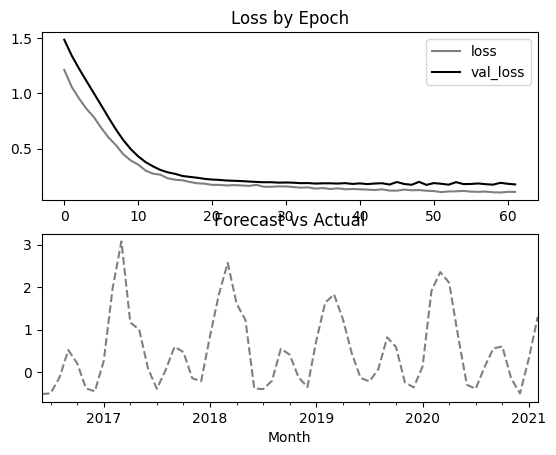

In [32]:
plot_forecast(model_en_simpleRNN, x_test_en, y_test_en, test_energy.index, history_en_simpleRNN)

In [42]:
from tensorflow.keras import Model
from keras.layers import Input, LSTM, GRU

In [35]:
def create_model(train, units, dropout=0.2):
    input_data = Input(shape=(10,1))
    rnn = SimpleRNN(units, return_sequences=True)(input_data)
    dropout = Dropout(dropout)(rnn)
    output = Dense(1)(dropout)
    model = Model(inputs=input_data, outputs=output)
    
    return model

### 2. Forecasting with LSTM using Keras

In [37]:
def create_model(train, units, dropout=0.2):
    model = keras.Sequential()
    model.add(LSTM(units=units, input_shape=(train.shape[1], train.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    
    return model

In [38]:
model_en_lstm = create_model(train=x_train_en, units=32)
model_en_lstm.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history_en_lstm = train_model_ts(model_en_lstm, x_train_en, y_train_en, x_val_en, y_val_en, batch_size=64)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 1.1007 - mean_absolute_error: 0.9032 - root_mean_squared_error: 1.0480 - val_loss: 1.4790 - val_mean_absolute_error: 0.8737 - val_root_mean_squared_error: 1.2161
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0335 - mean_absolute_error: 0.8767 - root_mean_squared_error: 1.0157 - val_loss: 1.4277 - val_mean_absolute_error: 0.8686 - val_root_mean_squared_error: 1.1948
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0134 - mean_absolute_error: 0.8731 - root_mean_squared_error: 1.0058 - val_loss: 1.3780 - val_mean_absolute_error: 0.8634 - val_root_mean_squared_error: 1.1739
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9787 - mean_absolute_error: 0.8599 - root_mean_squared_error: 0.9886 - val_loss: 1.3350 - val_mean_absolute_error: 0.8573 - val_root_mean_squared_error: 1.1554
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9555 - mean_absolute_error: 0.8514 - root_mean_squared_error

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step


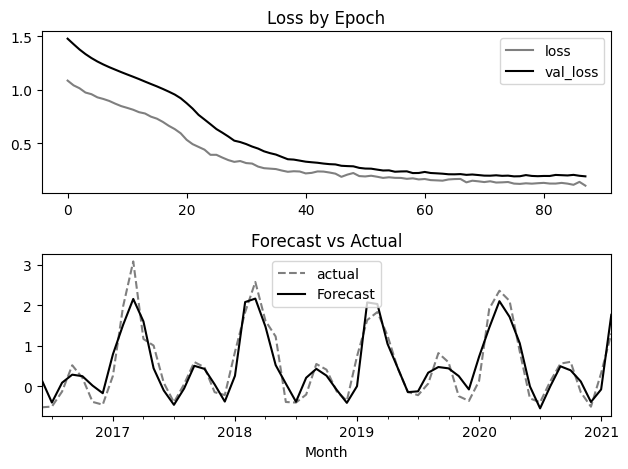

In [40]:
plot_forecast(model_en_lstm, x_test_en, y_test_en, test_energy.index, history_en_lstm)

In [41]:
from tensorflow.keras import Model
from keras.layers import (Dense, SimpleRNN, Dropout, Input)

def create_model(train, units, dropout=0.2):
    input_data = Input(shape=(10,1))
    lstm_1 = LSTM(units, return_sequences=True)(input_data)
    dropout_1 = Dropout(dropout)(lstm_1)
    lstm_2 = LSTM(units)(dropout_1)
    dropout_2 = Dropout(dropout)(lstm_2)
    output = Dense(1)(dropout_2)
    model = Model(inputs=input_data, outputs=output)
    
    return model

### 3. Forecasting with a GRU using Keras

In [43]:
def create_model(train, units, dropout=0.2):
    model = keras.Sequential()
    model.add(GRU(units=units, input_shape=(train.shape[1], train.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    
    return model

In [44]:
model_en_gru = create_model(x_train_en, units=32)
model_en_gru.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history_en_gru = train_model_ts(model_en_gru, x_train_en, y_train_en, x_val_en, y_val_en, batch_size=64)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 1.1419 - mean_absolute_error: 0.9177 - root_mean_squared_error: 1.0671 - val_loss: 1.4127 - val_mean_absolute_error: 0.8578 - val_root_mean_squared_error: 1.1886
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0308 - mean_absolute_error: 0.8750 - root_mean_squared_error: 1.0141 - val_loss: 1.3221 - val_mean_absolute_error: 0.8436 - val_root_mean_squared_error: 1.1498
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9610 - mean_absolute_error: 0.8473 - root_mean_squared_error: 0.9793 - val_loss: 1.2406 - val_mean_absolute_error: 0.8267 - val_root_mean_squared_error: 1.1138
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8995 - mean_absolute_error: 0.8214 - root_mean_squared_error: 0.9476 - val_loss: 1.1704 - val_mean_absolute_error: 0.8109 - val_root_mean_squared_error: 1.0818
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8411 - mean_absolute_error: 0.7940 - root_mean_squared_error

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x722bc1617920> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step


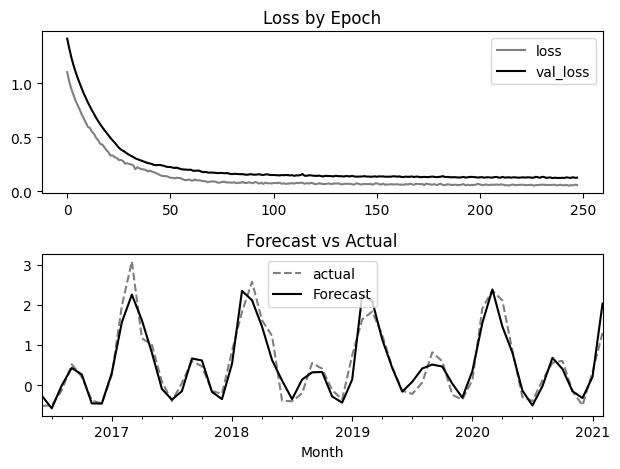

In [46]:
plot_forecast(model_en_gru, x_test_en, y_test_en, test_energy.index, history_en_gru)

The preceding code should produce two subplots, one for the training process (training loss and validation loss), and another comparing forecast against out-of-sample (test) data.

Note that the training ended at 248. Initially, the validation loss was lagging behind the training loss but then got reduced to an acceptable level.

### 4. Forecasting with an RNN using PyTorch

In [48]:
import matplotlib 
import pytorch_lightning as pl
import torch 

In [51]:
def features_target_pt(*args):
    y = [torch.from_numpy(col.pop('y').values.reshape(-1,1)).float() for col in args]
    x = [torch.from_numpy(col.values.reshape(*col.shape, 1)).float() for col in args]
    
    return *y, *x


In [52]:
(y_train_en, y_val_en, y_test_en, x_train_en, x_val_en, x_test_en) = features_target_pt(train_energy, val_energy, test_energy)

KeyError: 'y'

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

In [54]:
class RNN(nn.Module):
    def __init__(self, input_size, output_size, n_features, n_layers):
        super(RNN, self).__init__()
        self.n_layers = n_layers
        self.hidden_dim = n_features
        self.rnn = nn.RNN(input_size, n_features, n_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(n_features, output_size)

    def forward(self, x, hn):
        # batch_first=True -> (batch_size, seq_length, input_size)
        x = x.view(1, x.shape[0], x.shape[1])
        rnn_o, hn = self.rnn(x, hn)
        rnn_o = self.dropout(rnn_o)
        # reshape
        rnn_o = rnn_o.view(-1, self.hidden_dim)
        output = self.fc(rnn_o)

        return output, hn
    
    def init_hidden(self):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, 1, self.hidden_dim).zero_()

        return hidden

In [55]:
issubclass(RNN, nn.Module)

True

In [56]:
def train_model_pt(model_type='RNN', **kwargs):
    """
    Parameters:
        input_size: input size
        output_size: output size
        n_features: number of features (hidden dimension)
        n_layers: number of layers
        train_data: tuple ex (x_train, y_train)
        val_data: tuple ex (x_val, y_val)
        epochs: number of epochs
        print_every: output and history tracking
        lr: learning rate
    """
    if model_type=='RNN':
        model = RNN(kwargs['input_size'], 
                    kwargs['output_size'], 
                    kwargs['units'], 
                    kwargs['n_layers'])
    elif model_type=='LSTM':
        model = LSTM(kwargs['input_size'], 
                    kwargs['output_size'], 
                    kwargs['units'], 
                    kwargs['n_layers'])
    elif model_type=='GRU':
         model = LSTM(kwargs['input_size'], 
                    kwargs['output_size'], 
                    kwargs['units'], 
                    kwargs['n_layers'])
        
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=kwargs['lr'])
    
    x_train, y_train = kwargs['train_data']
    x_val, y_val  = kwargs['val_data']
    x_test, y_test = kwargs['test_data']
    
    history = {'loss': [], 'val_loss': []}
    # batch_size = x_train.shape[0]
    model.train()
    epochs = kwargs['epochs']
    print_every = kwargs['print_every']
    
    for batch_i, epoch in enumerate(range(epochs)):
        h = model.init_hidden()
        optimizer.zero_grad()
        pred, h = model(x_train, h) #model(x_train)
        #hidden = hidden.data
        loss = criterion(pred, y_train)        
        loss.backward()
        optimizer.step()
        if batch_i % print_every == 0:
            model.eval()
            with torch.no_grad():
                val_h = model.init_hidden()
                val_p, val_h = model(x_val, val_h)
                val_loss = criterion(val_p, y_val)
                history['val_loss'].append(val_loss.item())
            model.train()
            history['loss'].append(loss.item())
            print(f'{batch_i}/{epochs} - Loss:  {loss.item()}, val_loss: {val_loss.item()}')
    
    ## Prediction
    model.eval()
    with torch.no_grad():
        h0 = model.init_hidden()
        y_hat = model(x_test, h0)
    y_hat, _ = y_hat
    mse_loss_air = criterion(y_hat, y_test)
    print(f'Test MSE Loss: {mse_loss_air.item():.4f}')
    
    ## Plotting
    fig, ax = plt.subplots(2, 1) 

    ax[0].set_title(f'{model_type}: Loss and Validation Loss per epoch')
    ax[0].plot(history['loss'], 'k--', label='loss')
    ax[0].plot(history['val_loss'], 'k', label='val_loss')
    ax[0].legend()
    ax[1].set_title(f"{model_type} TEST MSE = {mse_loss_air.item():.4f}: Forecast vs Actual (Out-of-Sample data)")
    scale = kwargs['scale']
    actual = scale.inverse_y(y_test.detach().numpy().ravel())
    pred = scale.inverse_y(y_hat.detach().numpy().ravel())
    idx = kwargs['idx']
    pd.Series(actual, index=idx).plot(style='k--', label='actual', alpha=0.65)
    pd.Series(pred, index=idx).plot(style='k', label='forecast')
    fig.tight_layout()
    ax[1].legend(); plt.show()
    
    return model, history

In [57]:
params_en = {
    'input_size':x_train_en.shape[1],
    'output_size': 1,
    'units': 32,
    'n_layers': 1,
    'epochs': 500,
    'print_every': 20,
    'lr': 0.01,
    'train_data': (x_train_en, y_train_en),
    'val_data': (x_val_en, y_val_en),
    'test_data': (x_test_en, y_test_en),
    'idx': test_energy.index,
    'scale': scale_energy
}

en_rnn, history_en_rnn = train_model_pt('RNN', **params_en)

TypeError: view() takes from 0 to 2 positional arguments but 3 were given

In [58]:
# The following defines an RNN architecture with a dropout:
n_hidden = 32
input_size = x_train_en.shape[1]
n_layers = 1
output = 1
model = torch.nn.Sequential(
    torch.nn.RNN(input_size, n_hidden, n_layers),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(n_hidden, output)
)

### 5. Forecasting with LSTM using PyTorch

In [59]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, n_features, n_layers):
        super(LSTM, self).__init__()
        self.n_layers = n_layers
        self.hidden_dim = n_features
        self.lstm = nn.LSTM(input_size, n_features, n_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(n_features, output_size)
        
    def forward(self, x, hn):
        # batch_first=True -> (batch_size, seq_length, input_size)
        x = x.view(1, x.shape[0], x.shape[1])
        lstm_o, hn = self.lstm(x, hn)
        lstm_o = self.dropout(lstm_o)
        # reshape
        lstm_o = lstm_o.view(-1, self.hidden_dim)
        output = self.fc(lstm_o)
        return output, hn

    def init_hidden(self):
        weight = next(self.parameters()).data
        hidden = (weight.new(self.n_layers, 1, self.hidden_dim).zero_(),
                  weight.new(self.n_layers, 1, self.hidden_dim).zero_())
        return hidden

In [ ]:
en_lstm, history_en_lstm = train_model_pt('LSTM', **params_en)

In [61]:
# LSTM with Dropout
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, n_features, n_layers):
        super(LSTM, self).__init__()
        self.n_layers = n_layers
        self.hidden_dim = n_features
        self.lstm = nn.LSTM(input_size, n_features, n_layers, batch_first=True, dropout=0.70)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(n_features, output_size)
        
    def forward(self, x, hn):
        # batch_first=True -> (batch_size, seq_length, input_size)
        x = x.view(1, x.shape[0], x.shape[1])
        lstm_o, hn = self.lstm(x, hn)
        lstm_o = self.dropout(lstm_o)
        # reshape
        lstm_o = lstm_o.view(-1, self.hidden_dim)
        output = self.fc(lstm_o)
        return output, hn

    def init_hidden(self):
        weight = next(self.parameters()).data
        hidden = (weight.new(self.n_layers, 1, self.hidden_dim).zero_(),
                  weight.new(self.n_layers, 1, self.hidden_dim).zero_())
        return hidden

In [ ]:
en_lstm_d, history_en_lstm_d = train_model_pt('LSTM', **params_en)

In [63]:
# The following defines an LSTM architecture with a dropout:
n_hidden = 32
input_size = x_train_en.shape[1]
n_layers = 1
output = 1
model = torch.nn.Sequential(
    torch.nn.LSTM(input_size, n_hidden, n_layers),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(n_hidden, output)
)

### 6. Forecasting with a GRU using PyTorch

In [64]:
class GRU(nn.Module):
    def __init__(self, input_size, output_size, n_features, n_layers):
        super(GRU, self).__init__()
        self.n_layers = n_layers
        self.hidden_dim = n_features
        self.gru = nn.GRU(input_size, n_features, n_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(n_features, output_size)
        
    def forward(self, x, hn):
        # batch_first=True -> (batch_size, seq_length, input_size)
        x = x.view(1, x.shape[0], x.shape[1])
        gru_o, hn = self.gÇru(x, hn)
        gru_o = self.dropout(gru_o)
        # reshape
        gru_o = gru_o.view(-1, self.hidden_dim)
        output = self.fc(gru_o)

        return output, hn

    def init_hidden(self):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, 1, self.hidden_dim).zero_()
        
        return hidden

In [ ]:
en_gru, history_en_gru = train_model_pt('GRU', **params_en)

In [65]:
# The following defines the GRU architecture with a dropout:
n_hidden = 32
input_size = x_train_en.shape[1]
n_layers = 1
output = 1
model = torch.nn.Sequential(
    torch.nn.GRU(input_size, n_hidden, n_layers),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(n_hidden, output)
)